# Sándor Baranyi SNA project

# 1.1 Dataset and Network Description

## Dataset Overview
In this project, I analyze a social network of **Marvel Universe characters**. Each node represents a character, and an edge indicates that two characters appeared together in at least one comic book issue. This co-appearance network reflects how frequently characters are involved in shared storylines, making it a good example of a fictional but structured social system.

The dataset is split across two files:
- `marvel_nodes.csv`: A list of characters and their unique IDs.
- `marvel_edges.csv`: Connections between pairs of characters based on comic co-appearances.

## Network Characteristics
- **Type**: Undirected, unweighted graph
- **Domain**: Co-appearance / collaboration network in comics
- **Source**: Extracted from a `.gephi` file based on Marvel co-appearance data

## Preparation Steps
Originally, the dataset was stored in a `.gephi` file, which cannot be read directly with Python. I had to extract the data using the Gephi program. However, the file was outdated and incompatible with the current Gephi version, so I tracked down and installed **Gephi 0.9.2**, which supports the legacy format.

Using the **Data Laboratory** in Gephi, I manually exported the **nodes** and **edges** tables as separate `.csv` files. After that, I performed the following preprocessing steps:
- Verified all column names and encodings
- Dropped any duplicate or self-loop edges
- Checked that all edges reference valid character IDs in the nodes table

Overall, while the data was relatively clean, preparing it for analysis took some extra effort due to software compatibility issues.

## Sample View of the Dataset
Below I show a preview of both the nodes and edges files.


In [41]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np
from networkx.algorithms.community import greedy_modularity_communities

In [42]:
# Load CSVs
nodes_df = pd.read_csv("data/marvel_nodes.csv")
edges_df = pd.read_csv("data/marvel_edges.csv")

# Drop unused columns
nodes_df.drop(columns=["timeset"], inplace=True, errors="ignore")
edges_df.drop(columns=["timeset", "label", "Label"], inplace=True, errors="ignore")

# Preview cleaned data
print("Sample of nodes:")
print(nodes_df.head())

print("\nSample of edges:")
print(edges_df.head())

# Basic stats
print(f"\nNumber of characters (nodes): {len(nodes_df)}")
print(f"Number of relationships (edges): {len(edges_df)}")

Sample of nodes:
      Id                 Label
0  10470         LITTLE, ABNER
1  10471        PRINCESS ZANDA
2  10472  BLACK PANTHER/T'CHAL
3  10473  STEELE, SIMON/WOLFGA
4  10474      FORTUNE, DOMINIC

Sample of edges:
   Source  Target        Type      Id
0   10470   10476  Undirected  257707
1   10470   10613  Undirected  257708
2   10470   10625  Undirected  257706
3   10470   10827  Undirected  257710
4   10470   11508  Undirected  251494

Number of characters (nodes): 10469
Number of relationships (edges): 178115


# 1.2 Network Characterization

## Graph Creation
To analyze the Marvel co-appearance network, I used NetworkX to create an undirected graph from the edge list. Each node represents a character, and each edge represents a shared comic appearance.

## Giant Component
Since not all characters are connected, I extracted the largest connected component (GCC) to focus the analysis on the most meaningful part of the network. This avoids skewed statistics due to isolated nodes or small clusters.

## Basic Network Metrics
Here are the structural properties I calculated for the giant component:
- Number of nodes and edges (before and after extraction)
- Average degree
- Network diameter
- Average shortest path length
- Clustering coefficient

## Degree Distribution
To explore the nature of the network, I plotted the degree distribution on a log-log scale. This helps determine whether the network follows a power-law (scale-free), Poisson, or other distribution.

From visual inspection, the Marvel network shows characteristics of a scale-free network — a few nodes (characters) have very high degrees, while most have low degrees. This is common in collaboration networks where central figures co-appear with many others.


In [43]:
# Create full graph from edge list
G_full = nx.from_pandas_edgelist(edges_df, source="Source", target="Target")

# Basic stats on the full graph
print("Full graph stats:")
print(f"Number of nodes: {G_full.number_of_nodes()}")
print(f"Number of edges: {G_full.number_of_edges()}")

# Extract the largest connected component
largest_cc_nodes = max(nx.connected_components(G_full), key=len)
G = G_full.subgraph(largest_cc_nodes).copy()

print("\nGiant Component stats:")
print(f"Number of nodes: {G.number_of_nodes()}")
print(f"Number of edges: {G.number_of_edges()}")

Full graph stats:
Number of nodes: 10469
Number of edges: 178115

Giant Component stats:
Number of nodes: 10440
Number of edges: 178049


## Network Visualization

To provide a visual sense of the network structure, I plotted a sample of 150 nodes from the giant component. The full graph is too large to render meaningfully, but even the sample shows dense clustering and short paths — both common in real-world social networks.


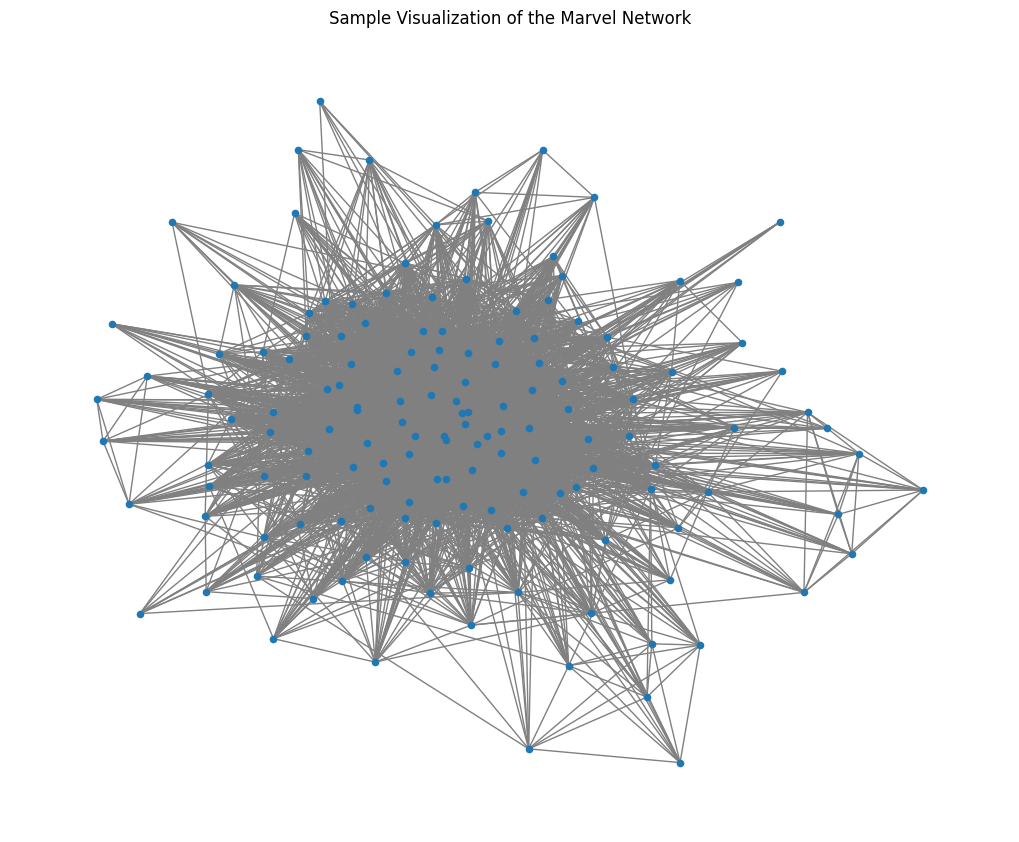

In [44]:
# Visualize a small subgraph to avoid overcrowding
sub_nodes = list(G.nodes())[:150]  # First 150 nodes
subgraph = G.subgraph(sub_nodes)

plt.figure(figsize=(10, 8))
nx.draw(subgraph, with_labels=False, node_size=20, edge_color='gray')
plt.title("Sample Visualization of the Marvel Network")
plt.show()

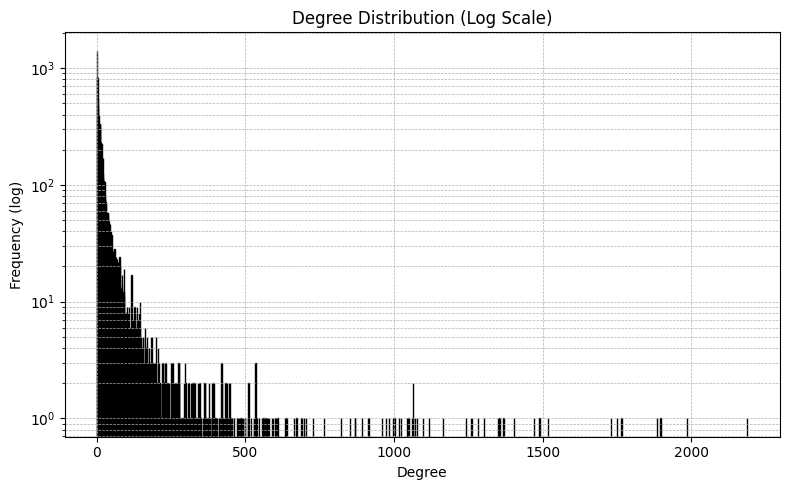

In [45]:
# Degree distribution
degrees = [deg for _, deg in G.degree()]
plt.figure(figsize=(8, 5))
plt.hist(degrees, bins=range(1, max(degrees)+1), log=True, edgecolor='black')
plt.title("Degree Distribution (Log Scale)")
plt.xlabel("Degree")
plt.ylabel("Frequency (log)")
plt.grid(True, which="both", linestyle="--", linewidth=0.5)
plt.tight_layout()
plt.show()


In [46]:
# Average degree
avg_degree = sum(dict(G.degree()).values()) / G.number_of_nodes()

# Clustering coefficient
clustering = nx.average_clustering(G)

# Diameter and average shortest path
diameter = nx.diameter(G)
avg_path_length = nx.average_shortest_path_length(G)

print(f"Average degree: {avg_degree:.2f}")
print(f"Clustering coefficient: {clustering:.4f}")
print(f"Network diameter: {diameter}")
print(f"Average shortest path length: {avg_path_length:.2f}")

Average degree: 34.11
Clustering coefficient: 0.4569
Network diameter: 7
Average shortest path length: 2.89


# 1.3 Centrality Measures

To understand the most important or influential characters in the Marvel network, I calculated several node centrality metrics:

- **Degree centrality**: Measures how many connections a node has.
- **Betweenness centrality**: Indicates how often a node appears on shortest paths between other nodes.
- **Closeness centrality**: Represents how close a node is to all other nodes in terms of path length.
- **PageRank**: Captures influence based on the number and quality of connections.

These measures help reveal which characters are central hubs, which ones connect different parts of the network, and which are well-positioned to spread information.

Below I show the top 10 characters for each measure and discuss their relevance.

> Note: I used the approximate version of betweenness centrality (`k=100`) due to the large size of the network. This significantly reduces runtime while still providing useful estimates.

> Note: Although PageRank was originally designed for directed networks, it can still be applied to undirected graphs by treating all edges as mutual. In this context, it gives a general sense of node influence based on the structure of the network.


In [47]:
# Degree Centrality
deg_cent = nx.degree_centrality(G)
top_deg = sorted(deg_cent.items(), key=lambda x: x[1], reverse=True)[:10]

# Betweenness Centrality
bet_cent = nx.betweenness_centrality(G, k=100, seed=42)
top_bet = sorted(bet_cent.items(), key=lambda x: x[1], reverse=True)[:10]

# Closeness Centrality
clo_cent = nx.closeness_centrality(G)
top_clo = sorted(clo_cent.items(), key=lambda x: x[1], reverse=True)[:10]

# PageRank
pagerank = nx.pagerank(G, alpha=0.85)
top_pagerank = sorted(pagerank.items(), key=lambda x: x[1], reverse=True)[:10]


In [48]:
# Helper function to get character name from ID
id_to_name = dict(zip(nodes_df["Id"], nodes_df["Label"]))

def display_top(title, centrality_list):
    print(f"\nTop 10 nodes by {title}:\n")
    for node_id, score in centrality_list:
        print(f"{id_to_name.get(node_id, node_id)}: {score:.4f}")

display_top("Degree Centrality", top_deg)
display_top("Betweenness Centrality", top_bet)
display_top("Closeness Centrality", top_clo)
display_top("PageRank", top_pagerank)



Top 10 nodes by Degree Centrality:

IRON MAN/TONY STARK: 0.2097
WOLVERINE/LOGAN: 0.1901
CAPTAIN AMERICA: 0.1816
SCARLET WITCH/WANDA: 0.1804
VISION: 0.1691
INVISIBLE WOMAN/SUE: 0.1676
SPIDER-MAN/PETER PAR: 0.1657
WASP/JANET VAN DYNE: 0.1453
DR. STRANGE/STEPHEN: 0.1426
PROFESSOR X/CHARLES: 0.1409

Top 10 nodes by Betweenness Centrality:

IRON MAN/TONY STARK: 0.0813
INVISIBLE WOMAN/SUE: 0.0786
DR. STRANGE/STEPHEN: 0.0644
SPIDER-MAN/PETER PAR: 0.0601
HAVOK/ALEX SUMMERS: 0.0561
SCARLET WITCH/WANDA: 0.0508
WOLVERINE/LOGAN: 0.0496
ICEMAN/ROBERT BOBBY: 0.0358
CAPTAIN AMERICA: 0.0340
JARVIS, EDWIN: 0.0337

Top 10 nodes by Closeness Centrality:

CAPTAIN AMERICA: 0.5408
SPIDER-MAN/PETER PAR: 0.5364
THING/BENJAMIN J. GR: 0.5264
MR. FANTASTIC/REED R: 0.5259
HUMAN TORCH/JOHNNY S: 0.5243
THOR/DR. DONALD BLAK: 0.5227
BEAST/HENRY &HANK& P: 0.5204
HULK/DR. ROBERT BRUC: 0.5171
HAWK: 0.5154
CYCLOPS/SCOTT SUMMER: 0.5148

Top 10 nodes by PageRank:

IRON MAN/TONY STARK: 0.0089
WOLVERINE/LOGAN: 0.0080
INVISI

## Interpretation of Results

As expected, characters like **Spider-Man**, **Captain America**, and **Iron Man** appear among the most central in multiple rankings. These figures tend to collaborate across different teams and story arcs, which increases their visibility in the network.

- **High degree centrality** usually indicates very collaborative characters.
- **High betweenness** often points to bridging roles — characters that connect different groups.
- **Closeness** reflects how efficiently a character can reach others, which may link to popularity.
- **PageRank** favors characters who are not only connected, but connected to other important ones.

Overall, these centrality measures provide complementary views of influence and structure in the Marvel universe.


# 1.4 Comparison with Random Network and Small-World Phenomena

To evaluate the structural uniqueness of the Marvel network, I compared it with a random graph generated using the Erdős–Rényi (ER) model. The ER graph has the same number of nodes and edges but edges are placed randomly.

I focused on two key comparisons:
- **Clustering coefficient**: Indicates how densely nodes form triangles (i.e., closed triplets).
- **Average shortest path length**: Reflects how easily information can spread through the network.

Real-world social networks typically exhibit **small-world properties**, meaning:
- High clustering (compared to ER graphs)
- Short average path length (comparable to ER)

If the Marvel network meets both criteria, it can be considered a small-world network.

Below are the computed metrics for both graphs.


In [49]:
# Get size of the real network
n_nodes = G.number_of_nodes()
n_edges = G.number_of_edges()
p = (2 * n_edges) / (n_nodes * (n_nodes - 1))  # Probability for ER model

# Generate Erdős–Rényi random graph
G_er = nx.gnm_random_graph(n=n_nodes, m=n_edges, seed=42)

# ER metrics
er_clustering = nx.average_clustering(G_er)

# Use sample estimation for average path length in ER graph
import random

sample_nodes = random.sample(list(G_er.nodes()), 100)
er_shortest_paths = []
for node in sample_nodes:
    lengths = nx.single_source_shortest_path_length(G_er, node)
    er_shortest_paths.extend(lengths.values())

er_avg_path = sum(er_shortest_paths) / len(er_shortest_paths)
er_diameter = max(er_shortest_paths)

print("Random Graph (ER) stats:")
print(f"Clustering coefficient: {er_clustering:.4f}")
print(f"Estimated average shortest path length: {er_avg_path:.2f}")
print(f"Estimated diameter: {er_diameter}")


Random Graph (ER) stats:
Clustering coefficient: 0.0033
Estimated average shortest path length: 2.92
Estimated diameter: 4


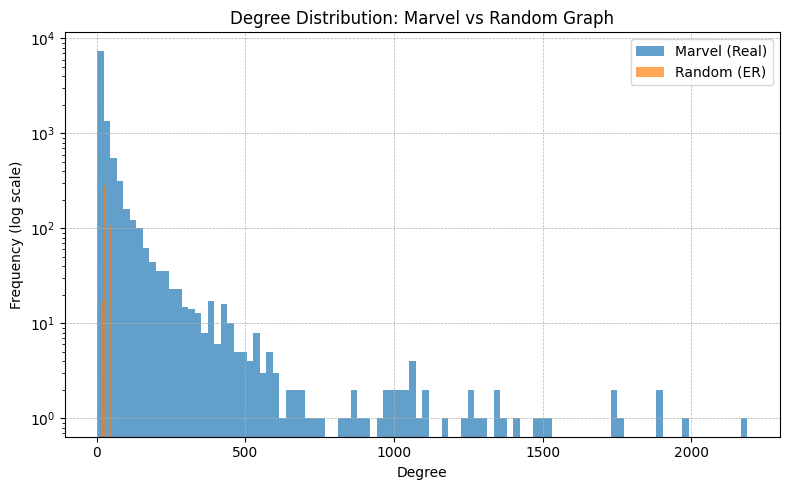

In [50]:
# Compare degree distributions: Marvel (real) vs ER (random)
real_degrees = [deg for _, deg in G.degree()]
random_degrees = [deg for _, deg in G_er.degree()]

plt.figure(figsize=(8, 5))
plt.hist(real_degrees, bins=100, alpha=0.7, label='Marvel (Real)', log=True)
plt.hist(random_degrees, bins=100, alpha=0.7, label='Random (ER)', log=True)
plt.xlabel("Degree")
plt.ylabel("Frequency (log scale)")
plt.title("Degree Distribution: Marvel vs Random Graph")
plt.legend()
plt.grid(True, linestyle="--", linewidth=0.5)
plt.tight_layout()
plt.show()


## Degree Distribution Comparison

This plot compares the degree distribution of the Marvel network with an equivalent Erdős–Rényi random graph. As expected, the random network displays a bell-shaped curve centered around its average degree — which reflects a **Poisson-like distribution**.

In contrast, the Marvel network follows a **long-tailed distribution**, where a small number of nodes have extremely high degrees. This supports the earlier claim that the network is **scale-free** and helps explain its vulnerability to targeted attacks.


In [51]:
# Reuse previously computed values
print("Marvel Network (GCC) stats:")
print(f"Clustering coefficient: {clustering:.4f}")
print(f"Average shortest path length: {avg_path_length:.2f}")
print(f"Diameter: {diameter}")


Marvel Network (GCC) stats:
Clustering coefficient: 0.4569
Average shortest path length: 2.89
Diameter: 7


## Interpretation

The Marvel network shows significantly **higher clustering** than the Erdős–Rényi random graph, which is expected in real-world social networks. While both networks have similar average path lengths and diameters, only the Marvel network maintains a tightly connected local structure.

This supports the idea that the Marvel co-appearance network exhibits **small-world characteristics**:
- High clustering (social grouping)
- Short paths between any two nodes (global efficiency)

These properties are typical of collaboration networks and further distinguish the structure from a purely random graph.

## Real-World Relevance

From a narrative perspective, the Marvel Universe is structured around a few key characters (like Iron Man and Spider-Man) who appear across many storylines. This is mirrored in the network structure: central hubs with high degrees and betweenness.

In technical terms, the combination of high clustering and short path lengths confirms that this is a **small-world network**, and its heavy-tailed degree distribution further aligns with **scale-free models** seen in sociology, biology, and technology.



# 2.1 Community Analysis

To detect communities in the Marvel network, I used the **Greedy Modularity** method. This algorithm identifies groups of nodes that are more densely connected internally than with the rest of the network, optimizing for modularity.

Each community typically corresponds to clusters of characters who co-appear frequently in the same storylines or comic arcs — such as the X-Men, Avengers, or Spider-Man’s universe.

## Summary
The analysis reveals how the network breaks into smaller, meaningful groups. I also compare these findings to earlier centrality measures to see which characters act as central figures within or between communities.


In [52]:
# Run the algorithm
communities = list(greedy_modularity_communities(G))

# Sort communities by size
communities_sorted = sorted(communities, key=len, reverse=True)

print(f"Number of communities found: {len(communities)}")

# Show sizes of the largest communities
print("\nTop 5 largest communities by number of characters:")
for i, comm in enumerate(communities_sorted[:5]):
    print(f"Community {i+1}: {len(comm)} nodes")


Number of communities found: 87

Top 5 largest communities by number of characters:
Community 1: 3767 nodes
Community 2: 2902 nodes
Community 3: 2797 nodes
Community 4: 218 nodes
Community 5: 67 nodes


In [53]:
# Show sample characters from top communities
for i, comm in enumerate(communities_sorted[:5]):
    names = [id_to_name.get(node, node) for node in list(comm)[:25]]
    print(f"\nCommunity {i+1} (sample members):")
    print(", ".join(names))


Community 1 (sample members):
,"KLOSS, BERNARD, EL GIBAR, ACHMED, ,"CHEEVER, JOHN, DELANY, CAPT., ,"WARHAWK II, TYGERSTRYKE/, PICO, TOLLIVER, WENDIGO III/FRANCOIS, ,"TYGERSTRYKE/, ,"GIDEON, ,"PICO, ,"WENDIGO III/FRANCOIS, THORNN II/LUCIA CALL, NICODEMUS II, BURKE, ,"OSAMA, CARDIAC/DR. ELI WIRT, FURMAN, RICHARD, TAKIMOTO, RON, HOBBS, DET., SATHAN, LUCIFER, REV., LUCIFER II, DOLAN, STACY

Community 2 (sample members):
,"COPYCAT/VANESSA, ,"WEAPON X II/GARRISON, ,"TOLLIVER, MUMM, MAX, ,"TAKIMOTO, RON, ,"HOBBS, DET., ,"CRIPPLER/KARL STRIKL, ,"SATHAN, ,"HUMAN ROBOT, ,"GORILLA-MAN, ,"3-D MAN/CHARLES CHAN, ,"MARVEL BOY III/ROBER, ,"VENUS II, ,"TEMPUS, ,"TYNDAR, ,"STARSHINE III/ANARRA, ,"LORD GASPAR, ,"KEL, JANOTH, ,"YOVA, ,"PULSAR II/LAN, ,"HAMMERHAND II/BRON, ,"JAVELIN II/DARIN JR., ,"XYOSS, ,"BIANDU, ,"LIBERATOR/PRINCE TRI

Community 3 (sample members):
MARVEL BOY III/ROBER, HUMAN ROBOT, GORILLA-MAN, 3-D MAN/CHARLES CHAN, VENUS II, TEMPUS, ALIOTH, REVELATION, MONGU, SPRAGG, DADDY LONGLEGS/R

In [54]:
# Pick the top 10 nodes from degree centrality
top_nodes = [node for node, _ in top_deg]
top_node_names = [id_to_name.get(node, node) for node in top_nodes]

# Map each node to its community index
node_to_community = {}
for i, comm in enumerate(communities_sorted):
    for node in comm:
        node_to_community[node] = i

print("Top central characters and their community assignments:\n")
for node in top_nodes:
    name = id_to_name.get(node, node)
    comm_id = node_to_community.get(node, None)
    print(f"{name} → Community {comm_id+1 if comm_id is not None else 'Not Found'}")


Top central characters and their community assignments:

IRON MAN/TONY STARK → Community 2
WOLVERINE/LOGAN → Community 1
CAPTAIN AMERICA → Community 3
SCARLET WITCH/WANDA → Community 2
VISION → Community 2
INVISIBLE WOMAN/SUE → Community 2
SPIDER-MAN/PETER PAR → Community 1
WASP/JANET VAN DYNE → Community 2
DR. STRANGE/STEPHEN → Community 2
PROFESSOR X/CHARLES → Community 1


## Interpretation

The community detection algorithm split the network into several distinct groups. Interestingly, some of the most central characters from earlier analysis — such as **Spider-Man**, **Iron Man**, **Wolverine**, and **Captain America** — are indeed found in the top communities, though not necessarily the very largest one.

For example:
- **Spider-Man** and **Wolverine** are in **Community 1**
- **Iron Man**, **Scarlet Witch**, **Vision**, and **Dr. Strange** all appear in **Community 2**
- **Captain America** shows up in **Community 3**

This confirms that many of the high-centrality nodes are not isolated; they’re embedded within strong, interconnected communities. Their appearance in different clusters also supports the idea that they act as **bridges between groups**, consistent with their high **betweenness** and **degree centrality**.

Overall, there is a clear relationship between centrality and community structure, but it's not always direct. Some influential characters are embedded in dense clusters, while others serve more as connectors between them.


# 2.2 Network Dynamics: Robustness

To study how the Marvel network behaves under stress, I simulated two types of node removal:

1. **Random failures** – nodes are removed in random order (like accidental losses).
2. **Targeted attacks** – nodes are removed starting from the most connected ones (intentional attacks on hubs).

For each scenario, I tracked the relative size of the **giant connected component (GCC)** after each step. This tells me how “intact” the network remains.

## Results

- The network is highly **robust to random failures**. Even after removing hundreds of nodes at random, the giant component stays mostly connected.
- Under **targeted attacks**, the structure collapses quickly. Removing high-degree nodes breaks the network into many disconnected parts.
- This is typical for **scale-free networks**, where a few nodes hold the structure together.

These findings confirm that the Marvel network relies heavily on central characters like **Iron Man**, **Spider-Man**, and **Wolverine** to maintain connectivity.


In [55]:
# Number of steps in the simulation
steps = 50
removal_counts = np.linspace(0, G.number_of_nodes(), steps, dtype=int)

# Get sorted node lists
random_nodes = list(G.nodes())
targeted_nodes = sorted(G.degree, key=lambda x: x[1], reverse=True)
targeted_nodes = [n for n, _ in targeted_nodes]

# Track GCC size over time
random_gcc = []
targeted_gcc = []

for i in removal_counts:
    # --- Random ---
    G_rand = G.copy()
    G_rand.remove_nodes_from(random_nodes[:i])
    if len(G_rand) > 0:
        largest_cc = max(nx.connected_components(G_rand), key=len)
        random_gcc.append(len(largest_cc) / G.number_of_nodes())
    else:
        random_gcc.append(0)

    # --- Targeted ---
    G_target = G.copy()
    G_target.remove_nodes_from(targeted_nodes[:i])
    if len(G_target) > 0:
        largest_cc = max(nx.connected_components(G_target), key=len)
        targeted_gcc.append(len(largest_cc) / G.number_of_nodes())
    else:
        targeted_gcc.append(0)


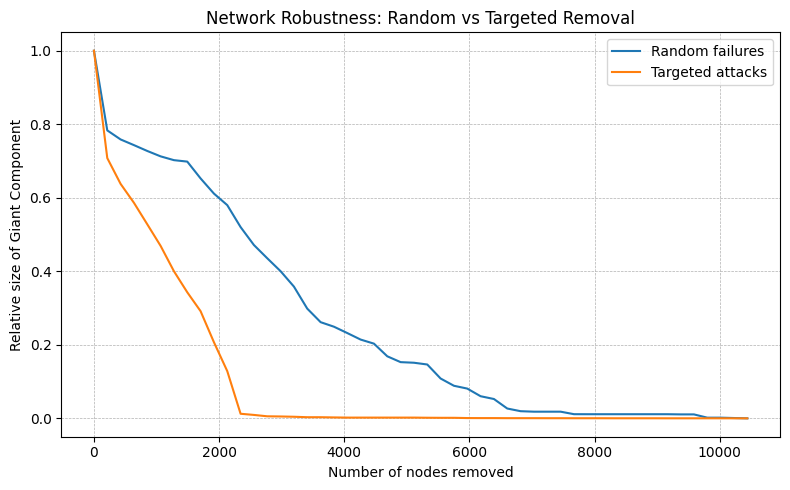

In [56]:
plt.figure(figsize=(8, 5))
plt.plot(removal_counts, random_gcc, label="Random failures")
plt.plot(removal_counts, targeted_gcc, label="Targeted attacks")
plt.xlabel("Number of nodes removed")
plt.ylabel("Relative size of Giant Component")
plt.title("Network Robustness: Random vs Targeted Removal")
plt.legend()
plt.grid(True, linestyle="--", linewidth=0.5)
plt.tight_layout()
plt.show()


## Interpretation

The network is highly robust to **random failures** — removing many random characters has little effect on the giant component.

However, under **targeted attacks** (removing the most connected characters first), the network breaks apart quickly. This is a typical behavior of **scale-free networks**, which depend heavily on a small number of highly connected nodes.

In the Marvel universe, this means that a few key characters like **Spider-Man**, **Iron Man**, or **Captain America** are critical to holding the universe together structurally. If they’re removed, the network fragments.

This analysis shows that while the network is resilient to random disruptions, it's highly vulnerable to targeted attacks — a signature of real-world collaboration networks.


# 2.3 Conclusions and Assessment

In this project, I applied Social Network Analysis techniques to the Marvel character co-appearance network. The goal was to explore its structural properties, identify influential nodes and communities, and simulate how the network behaves under stress.

---

## Summary of Key Findings

### Network Structure
- After cleaning and extracting the giant component, the network included over **10,000 characters** and **178,000+ edges**.
- The **degree distribution** followed a heavy-tailed shape, typical of **scale-free networks**, where most nodes have few connections, and a few (like **Iron Man** and **Spider-Man**) have many.
- The Marvel network showed **small-world properties**: high clustering (compared to a random graph) and short average path lengths.

---

### Centrality and Key Nodes
- The most central characters by multiple measures (degree, betweenness, closeness, PageRank) included:
  - **Iron Man**
  - **Spider-Man**
  - **Wolverine**
  - **Captain America**
- These characters often serve as **bridges** between communities and help hold the network together.

---

### Community Structure
- The network was divided into multiple communities using **Greedy Modularity** clustering.
- Central characters were distributed across different groups:
  - **Spider-Man** and **Professor X** appeared in Community 1
  - **Iron Man** and **Scarlet Witch** were in Community 2
  - **Captain America** was in Community 3
- This supports the idea that important characters act as **connectors** across groups, rather than being locked into one cluster.

---

### Network Dynamics: Robustness
- The network was **resilient to random failures**: removing random characters had little impact on overall connectivity.
- Under **targeted attacks** (removing high-degree nodes), the network collapsed quickly.
- This behavior is characteristic of **scale-free networks** and highlights the structural importance of central nodes.

---

## Final Assessment
The Marvel character network exhibits all the hallmarks of a complex, real-world system: scale-free structure, small-world properties, clustered communities, and central hubs that hold everything together.

The analysis not only revealed how the Marvel universe is organized narratively but also showed how social network theory applies to fictional collaboration networks.

Overall, this project helped me understand both the **technical** and **interpretive** sides of Social Network Analysis — from building graphs and running algorithms to making sense of real-world implications.
